In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, f1_score, precision_score,
                              recall_score, accuracy_score)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
print("✅ All libraries imported")

✅ All libraries imported


In [3]:
df = pd.read_csv('heart.csv')

In [4]:
print(f"Shape     : {df.shape}")


Shape     : (1025, 14)


In [5]:
 print(f"Missing   : {df.isnull().sum().sum()}")

Missing   : 0


In [6]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 723


In [7]:
df = df.drop_duplicates()

In [8]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [9]:
print("\nFeature Summary:")
print(df.describe().T[['mean','std','min','max']].round(2))


Feature Summary:
            mean    std    min    max
age        54.42   9.05   29.0   77.0
sex         0.68   0.47    0.0    1.0
cp          0.96   1.03    0.0    3.0
trestbps  131.60  17.56   94.0  200.0
chol      246.50  51.75  126.0  564.0
fbs         0.15   0.36    0.0    1.0
restecg     0.53   0.53    0.0    2.0
thalach   149.57  22.90   71.0  202.0
exang       0.33   0.47    0.0    1.0
oldpeak     1.04   1.16    0.0    6.2
slope       1.40   0.62    0.0    2.0
ca          0.72   1.01    0.0    4.0
thal        2.31   0.61    0.0    3.0
target      0.54   0.50    0.0    1.0


In [10]:
print("\nTarget Distribution:")
print(df['target'].value_counts())


Target Distribution:
target
1    164
0    138
Name: count, dtype: int64


In [11]:
print(f"Class Balance: {df['target'].mean()*100:.1f}% positive")

Class Balance: 54.3% positive


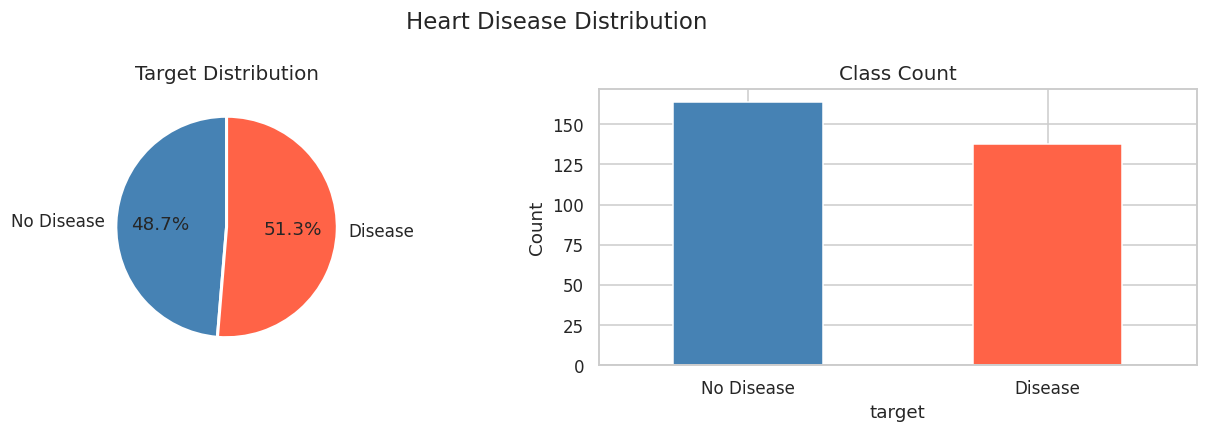

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie([499, 526], labels=['No Disease', 'Disease'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Target Distribution')

df['target'].value_counts().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Disease', 'Disease'], rotation=0)
axes[1].set_title('Class Count')
axes[1].set_ylabel('Count')

plt.suptitle('Heart Disease Distribution', fontsize=15)
plt.tight_layout()
plt.show()

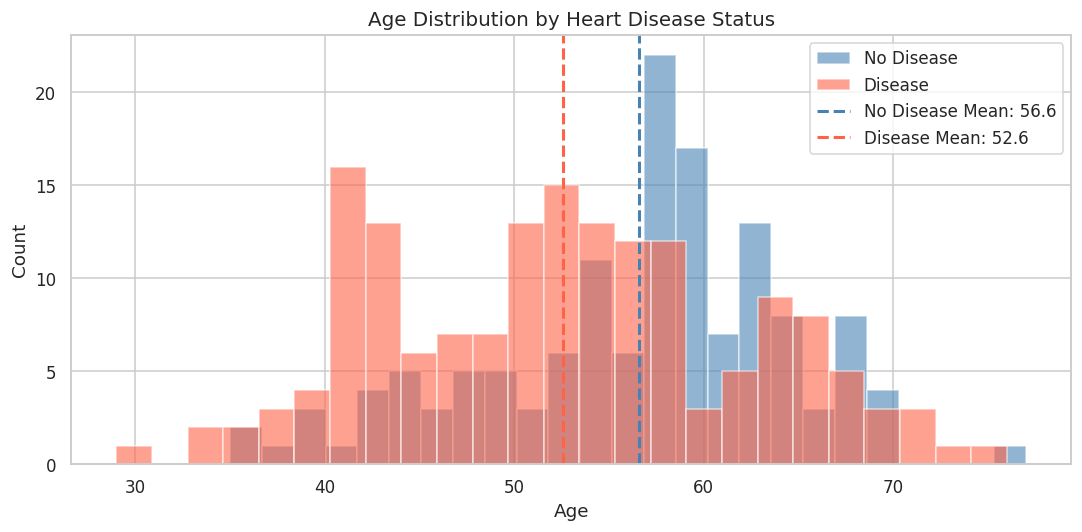

In [13]:
plt.figure(figsize=(10, 5))
df[df['target']==0]['age'].hist(bins=25, alpha=0.6,
    color='steelblue', label='No Disease', edgecolor='white')
df[df['target']==1]['age'].hist(bins=25, alpha=0.6,
    color='tomato', label='Disease', edgecolor='white')
plt.axvline(df[df['target']==0]['age'].mean(),
            color='steelblue', linestyle='--', lw=2,
            label=f"No Disease Mean: {df[df['target']==0]['age'].mean():.1f}")
plt.axvline(df[df['target']==1]['age'].mean(),
            color='tomato', linestyle='--', lw=2,
            label=f"Disease Mean: {df[df['target']==1]['age'].mean():.1f}")
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


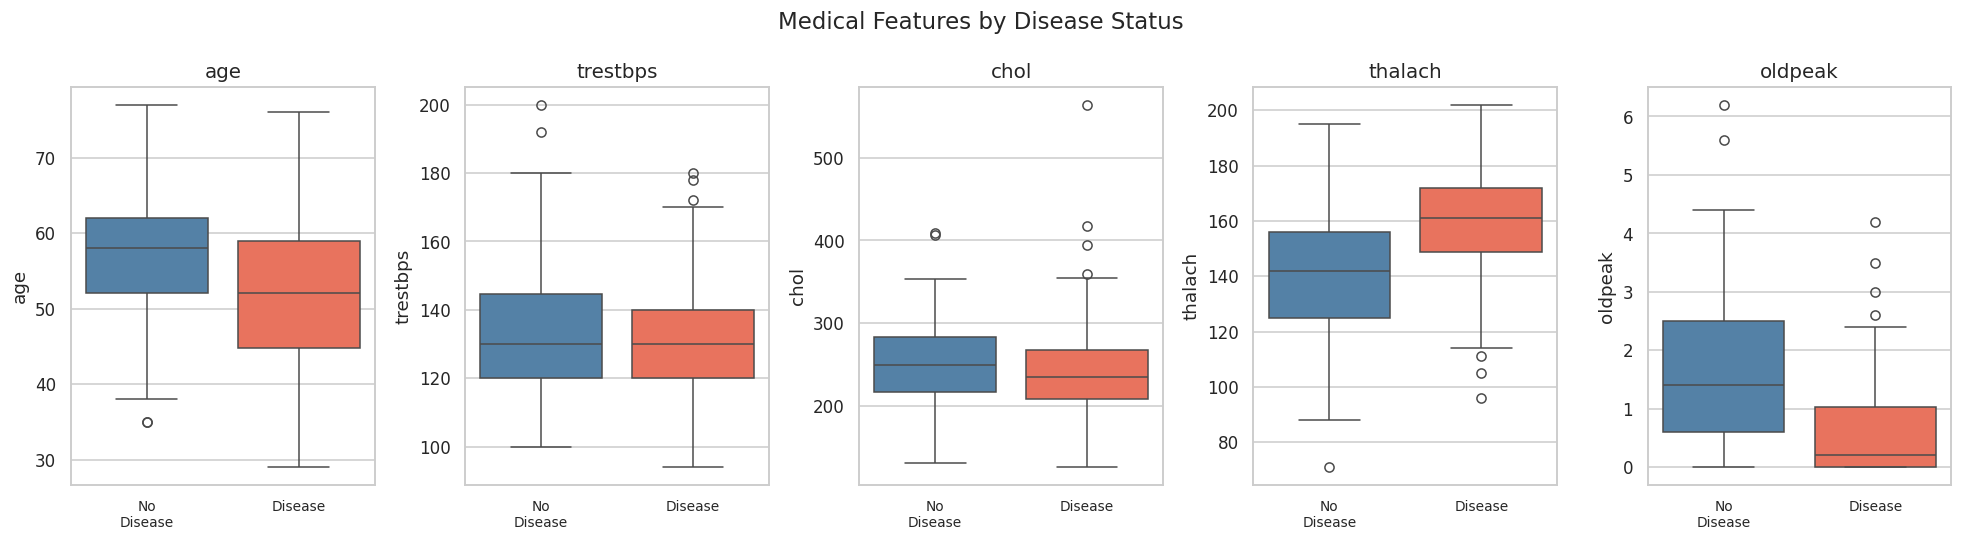

In [14]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, num_features):
    sns.boxplot(data=df, x='target', y=col, ax=ax,
                hue='target',
                palette={0:'steelblue', 1:'tomato'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No\nDisease', 'Disease'], fontsize=9)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Medical Features by Disease Status', fontsize=15)
plt.tight_layout()
plt.show()

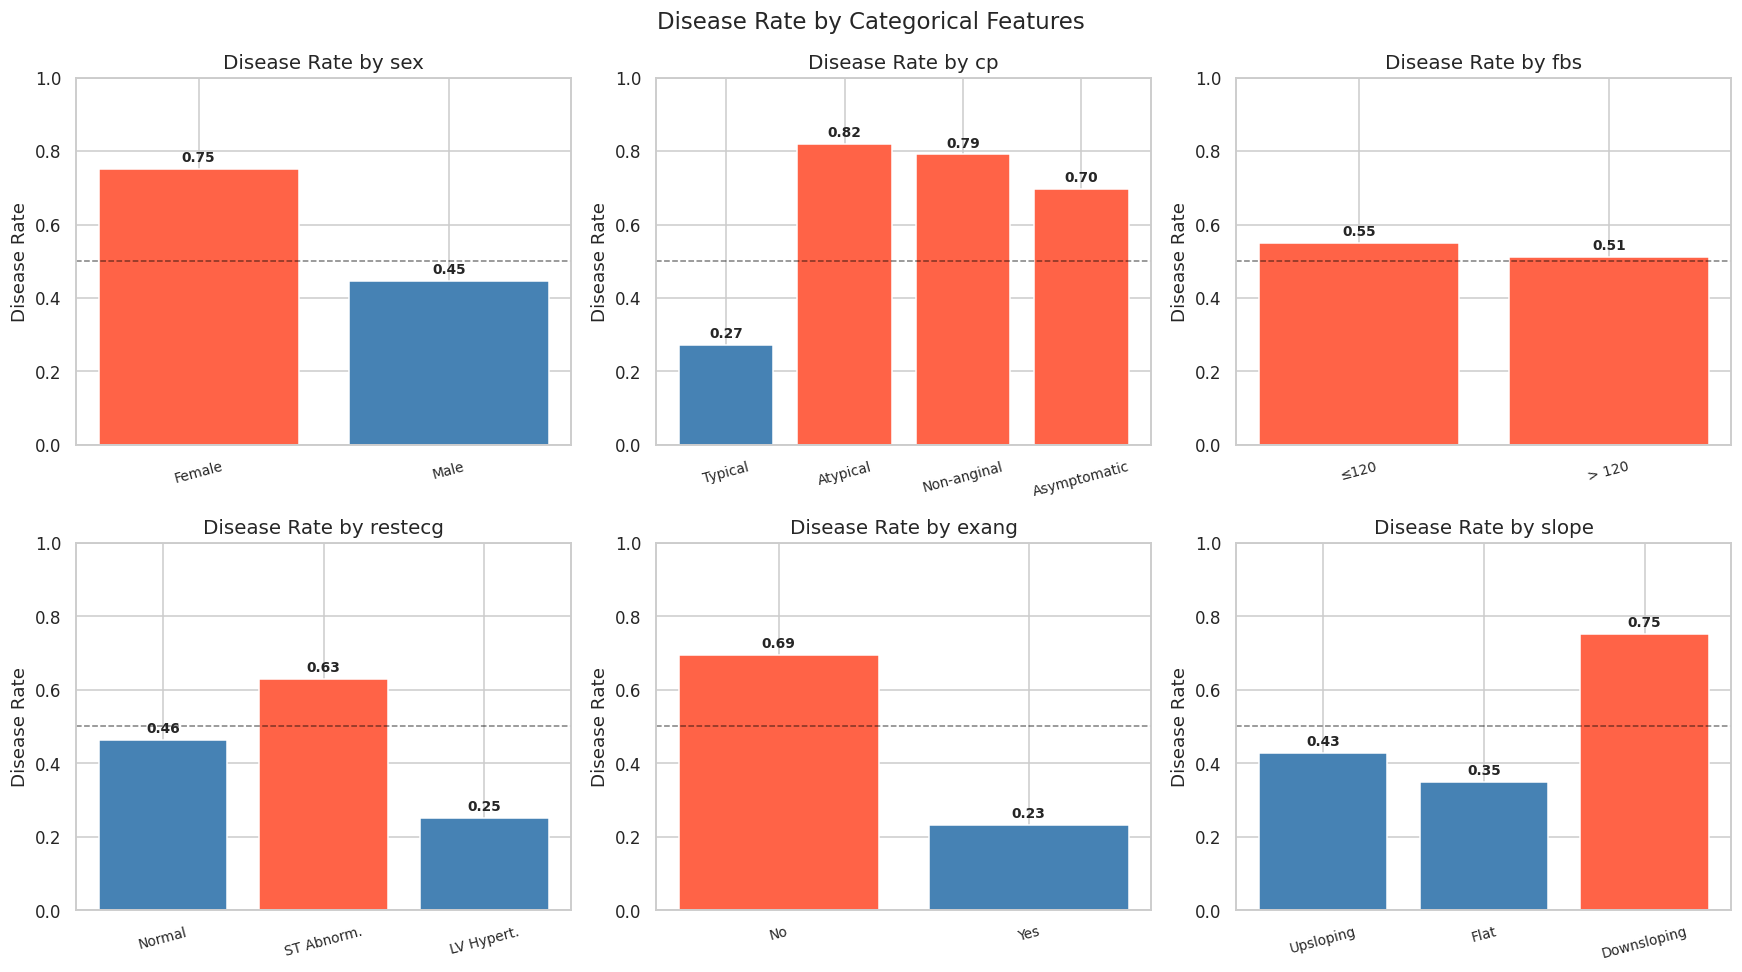

In [15]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
labels = {
    'sex'    : ['Female','Male'],
    'cp'     : ['Typical','Atypical','Non-anginal','Asymptomatic'],
    'fbs'    : ['≤120','> 120'],
    'restecg': ['Normal','ST Abnorm.','LV Hypert.'],
    'exang'  : ['No','Yes'],
    'slope'  : ['Upsloping','Flat','Downsloping']
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    ct = df.groupby(col)['target'].mean().reset_index()
    bars = ax.bar(range(len(ct)), ct['target'],
                  color=['steelblue' if v < 0.5 else 'tomato'
                         for v in ct['target']],
                  edgecolor='white')
    if col in labels:
        ax.set_xticks(range(len(ct)))
        ax.set_xticklabels(labels[col], rotation=15, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Disease Rate by {col}')
    ax.set_ylabel('Disease Rate')
    ax.axhline(0.5, color='black', linestyle='--', lw=1, alpha=0.5)
    for bar, val in zip(bars, ct['target']):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.02, f'{val:.2f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Disease Rate by Categorical Features', fontsize=15)
plt.tight_layout()
plt.show()

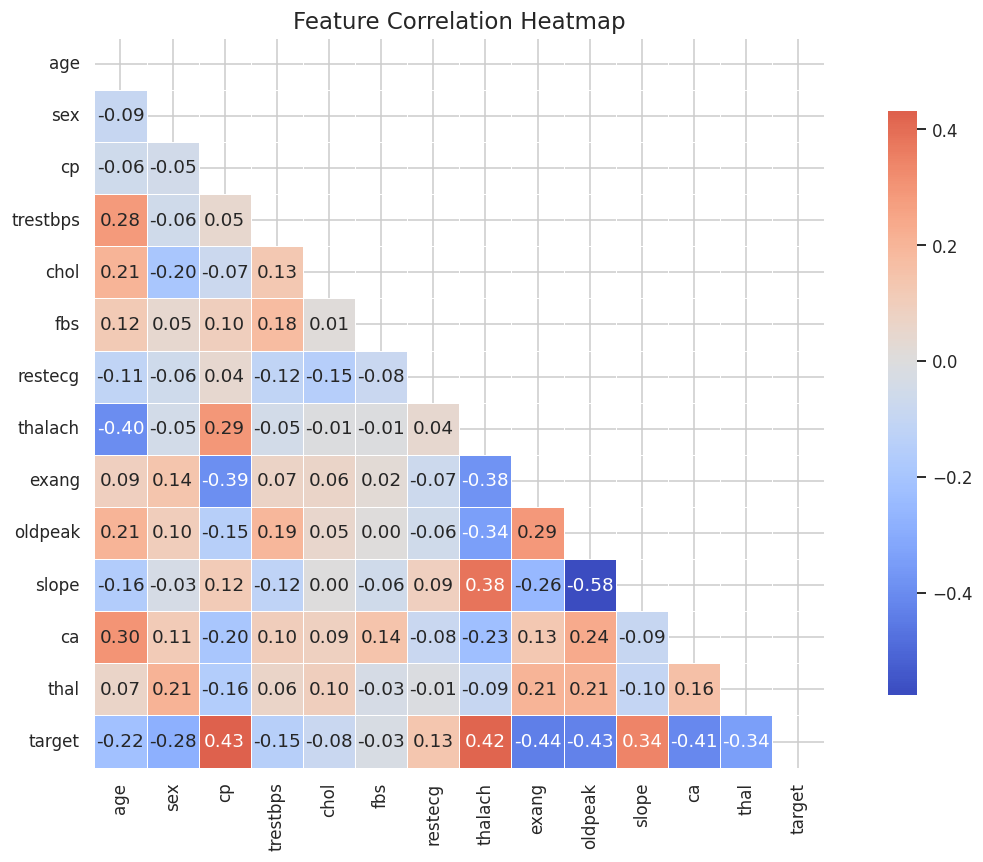

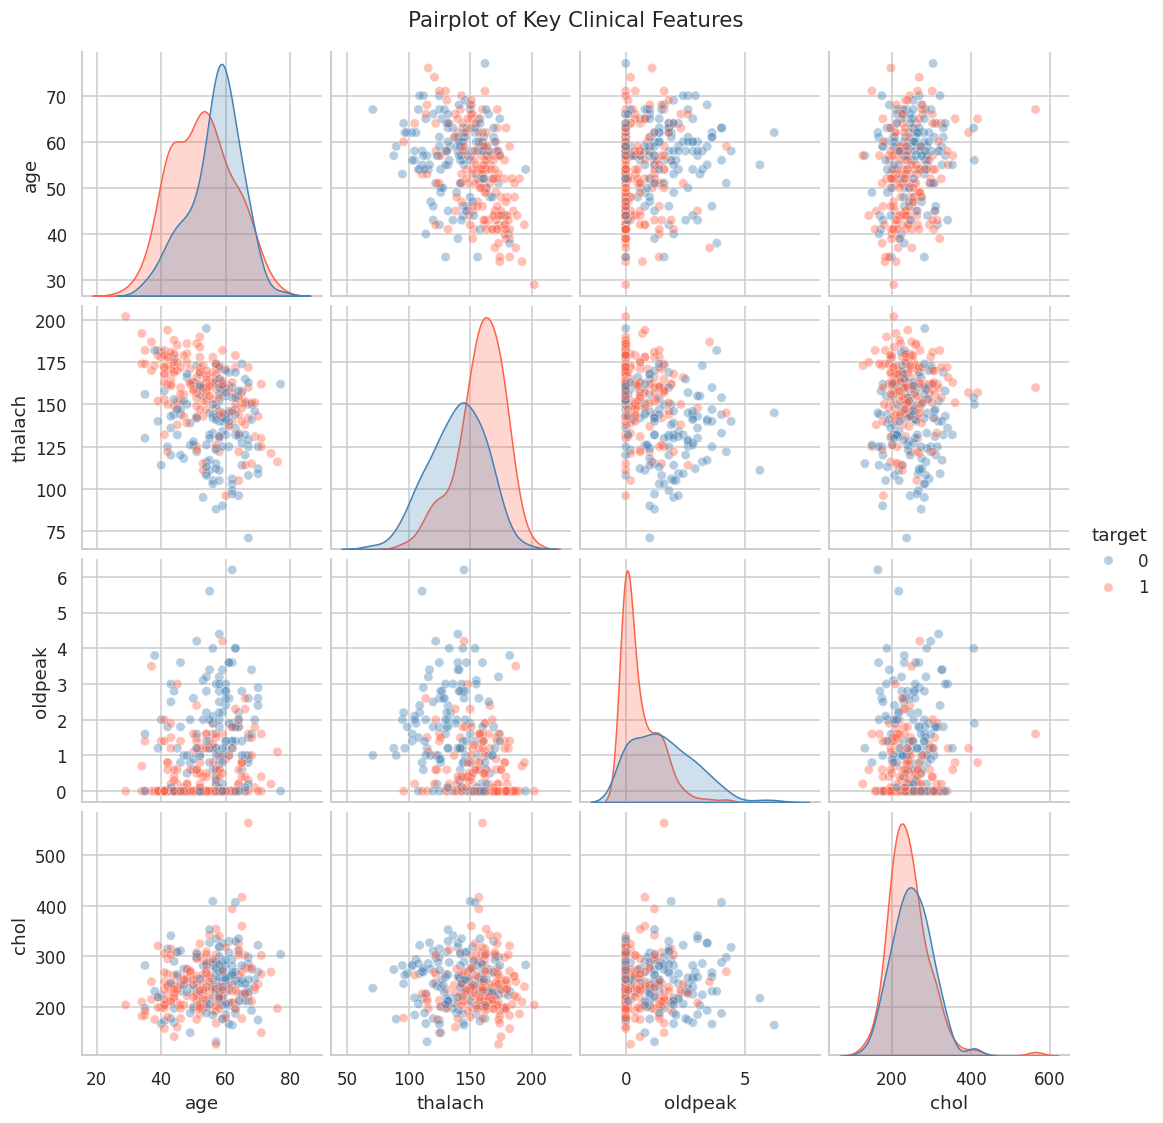

In [16]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

# ── 6. Pairplot of Key Clinical Features ─────────────────────────
key_features = ['age', 'thalach', 'oldpeak', 'chol', 'target']
sns.pairplot(df[key_features], hue='target',
             palette={0:'steelblue', 1:'tomato'},
             plot_kws={'alpha': 0.4}, diag_kind='kde')
plt.suptitle('Pairplot of Key Clinical Features', y=1.02, fontsize=14)
plt.show()

In [17]:
df['age_thalach_ratio'] = df['age'] / (df['thalach'] + 1)
df['chol_age']          = df['chol'] * df['age']
df['bp_chol_ratio']     = df['trestbps'] / (df['chol'] + 1)

In [18]:
X = df.drop(columns=['target'])
y = df['target']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train balance: {y_train.mean()*100:.1f}% positive")

Train: (241, 16) | Test: (61, 16)
Train balance: 54.4% positive


In [21]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

feature_names = X.columns.tolist()

In [22]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print("✅ Logistic Regression trained")

✅ Logistic Regression trained


In [23]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)
svm.fit(X_train_sc, y_train)
svm_pred  = svm.predict(X_test_sc)
svm_proba = svm.predict_proba(X_test_sc)[:, 1]

print("✅ SVM trained")

✅ SVM trained


In [24]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained")

✅ Random Forest trained


In [26]:
xgb = XGBClassifier(n_estimators=200, max_depth=5,
                     learning_rate=0.05, subsample=0.8,
                     colsample_bytree=0.8,
                     eval_metric='logloss',
                     random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)], verbose=False)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
print("✅ XGBoost trained")


✅ XGBoost trained


In [27]:
models = {
    'Logistic Regression': (lr_pred,  lr_proba,  'steelblue'),
    'SVM'                : (svm_pred, svm_proba, 'darkorange'),
    'Random Forest'      : (rf_pred,  rf_proba,  'green'),
    'XGBoost'            : (xgb_pred, xgb_proba, 'purple')
}

In [28]:
for name, (pred, proba, _) in models.items():
    print(f"\n{'═'*55}")
    print(f"  {name}")
    print(f"{'═'*55}")
    print(classification_report(y_test, pred,
          target_names=['No Disease', 'Disease']))
    print(f"  ROC-AUC : {roc_auc_score(y_test, proba):.4f}")


═══════════════════════════════════════════════════════
  Logistic Regression
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

  ROC-AUC : 0.8701

═══════════════════════════════════════════════════════
  SVM
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Disease       0.77      0.71      0.74        28
     Disease       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

  ROC-AUC : 0.8333

═════════════════════════════════════════════════════

In [29]:
rows = []
for name, (pred, proba, _) in models.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall'   : recall_score(y_test, pred),
        'F1-Score' : f1_score(y_test, pred),
        'ROC-AUC'  : roc_auc_score(y_test, proba)
    })

In [30]:
comp = pd.DataFrame(rows).set_index('Model').round(4)
print("\n" + "═"*65)
print("              COMPLETE MODEL COMPARISON")
print("═"*65)
print(comp.to_string())

# Highlight best per metric
print("\n🏆 Best per metric:")
for col in comp.columns:
    best = comp[col].idxmax()
    print(f"  {col:12s}: {best} ({comp.loc[best, col]:.4f})")


═════════════════════════════════════════════════════════════════
              COMPLETE MODEL COMPARISON
═════════════════════════════════════════════════════════════════
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8033     0.8000  0.8485    0.8235   0.8701
SVM                    0.7705     0.7714  0.8182    0.7941   0.8333
Random Forest          0.7541     0.7812  0.7576    0.7692   0.8550
XGBoost                0.7377     0.7576  0.7576    0.7576   0.8355

🏆 Best per metric:
  Accuracy    : Logistic Regression (0.8033)
  Precision   : Logistic Regression (0.8000)
  Recall      : Logistic Regression (0.8485)
  F1-Score    : Logistic Regression (0.8235)
  ROC-AUC     : Logistic Regression (0.8701)


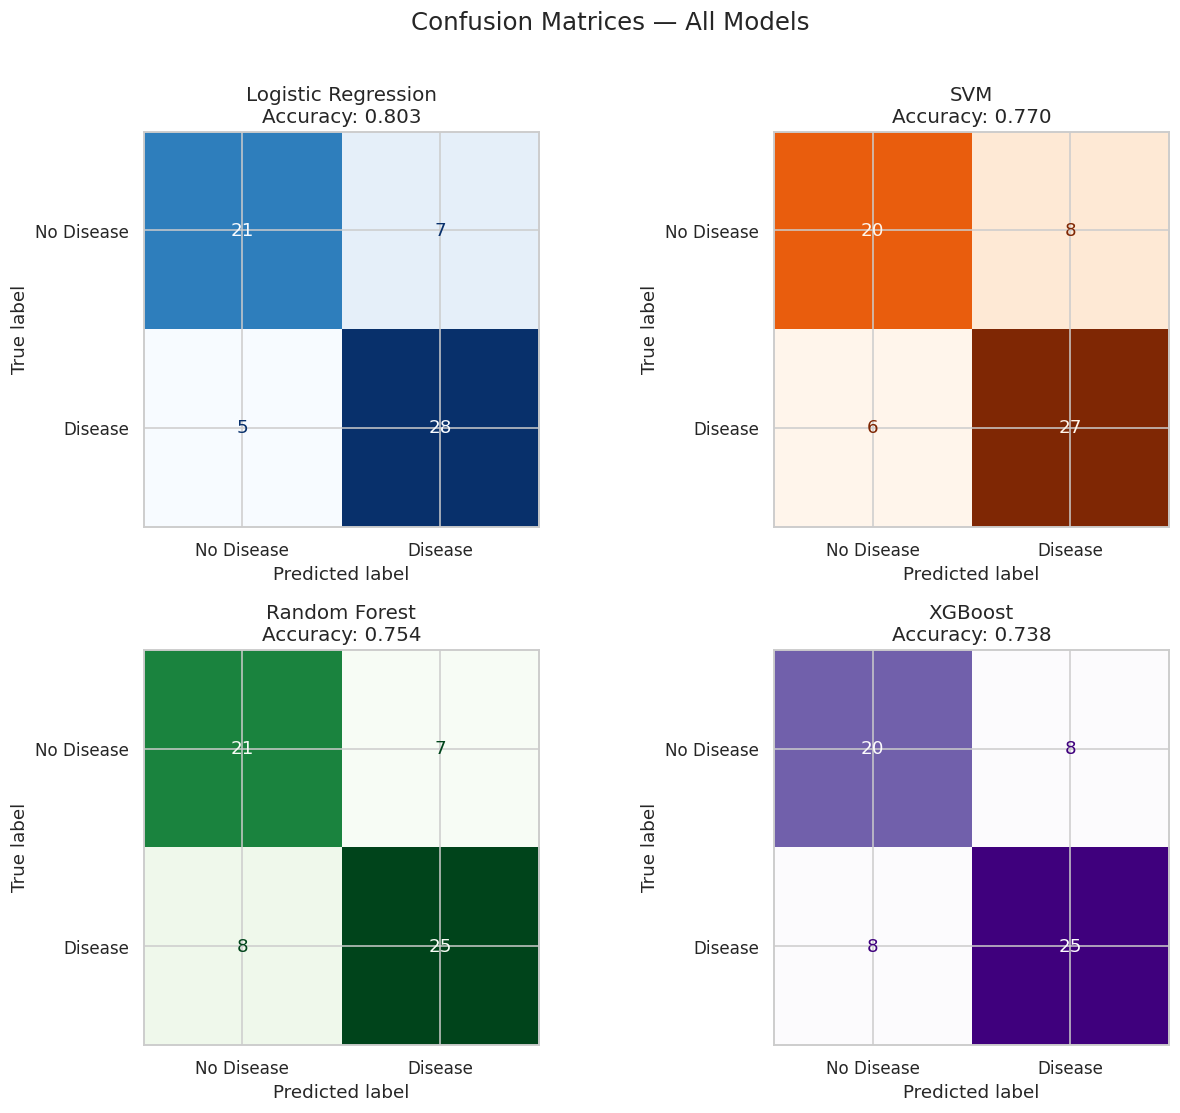

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, (name, (pred, _, __)), cmap in zip(axes, models.items(), cmaps):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease']).plot(
        ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

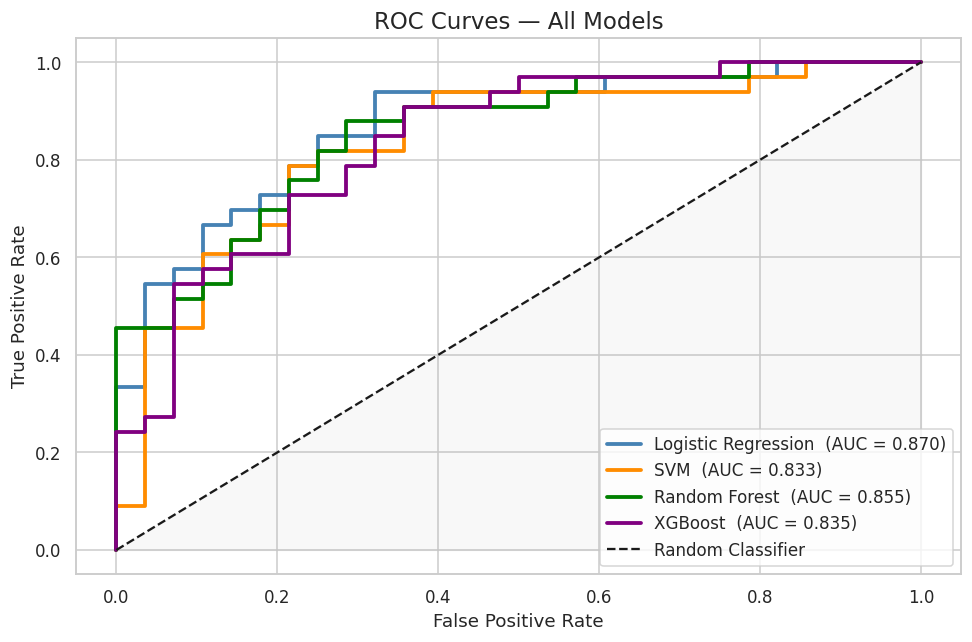

In [32]:
plt.figure(figsize=(9, 6))
for name, (_, proba, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between([0,1],[0,1], alpha=0.05, color='grey')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=15)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

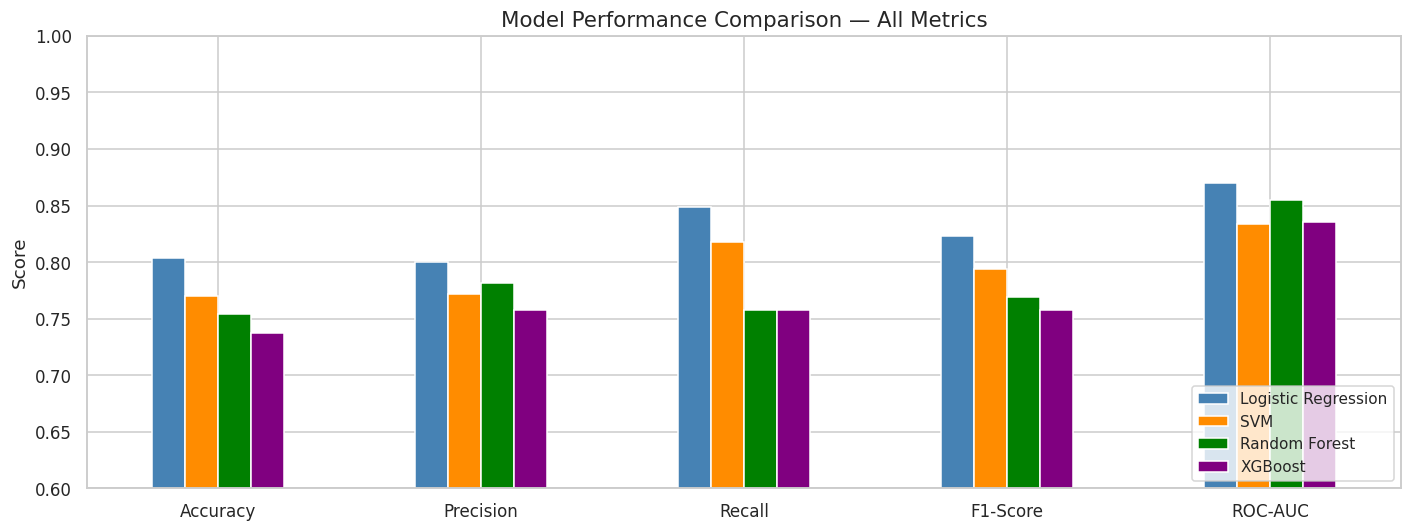

In [33]:
# ── Metric Radar / Bar Comparison ────────────────────────────────
comp.T.plot(kind='bar', figsize=(13, 5),
            color=['steelblue', 'darkorange', 'green', 'purple'],
            edgecolor='white')
plt.title('Model Performance Comparison — All Metrics', fontsize=14)
plt.ylabel('Score')
plt.ylim(0.6, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

── 5-Fold Stratified Cross-Validation ──────────────────────
  Logistic Regression      : 0.9114 ± 0.0397  [0.8689 – 0.9697]
  SVM                      : 0.9062 ± 0.0404  [0.8462 – 0.9630]
  Random Forest            : 0.9030 ± 0.0522  [0.8287 – 0.9731]
  XGBoost                  : 0.9081 ± 0.0368  [0.8479 – 0.9478]


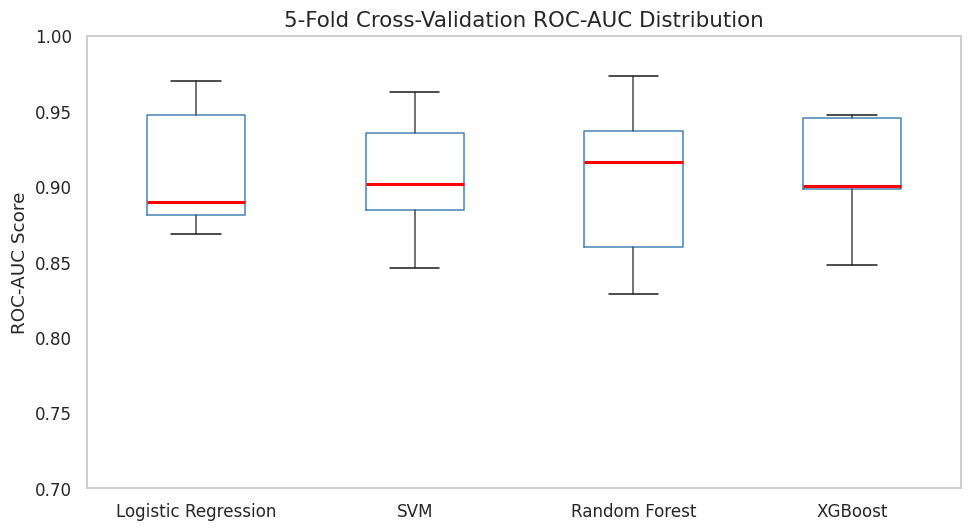

In [37]:
print("── 5-Fold Stratified Cross-Validation ──────────────────────")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_data = [
    ('Logistic Regression', lr,  X_train_sc, y_train),
    ('SVM',                 svm, X_train_sc, y_train),
    ('Random Forest',       rf,  X_train,    y_train),
    ('XGBoost',             xgb, X_train,    y_train),
]

cv_results = {}
for name, model, Xtr, ytr in cv_data:
    scores = cross_val_score(model, Xtr, ytr, cv=skf,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"[{scores.min():.4f} – {scores.max():.4f}]")

# CV Boxplot
plt.figure(figsize=(9, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(9, 5), grid=False,
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='red', lw=2))
plt.title('5-Fold Cross-Validation ROC-AUC Distribution', fontsize=14)
plt.ylabel('ROC-AUC Score')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()


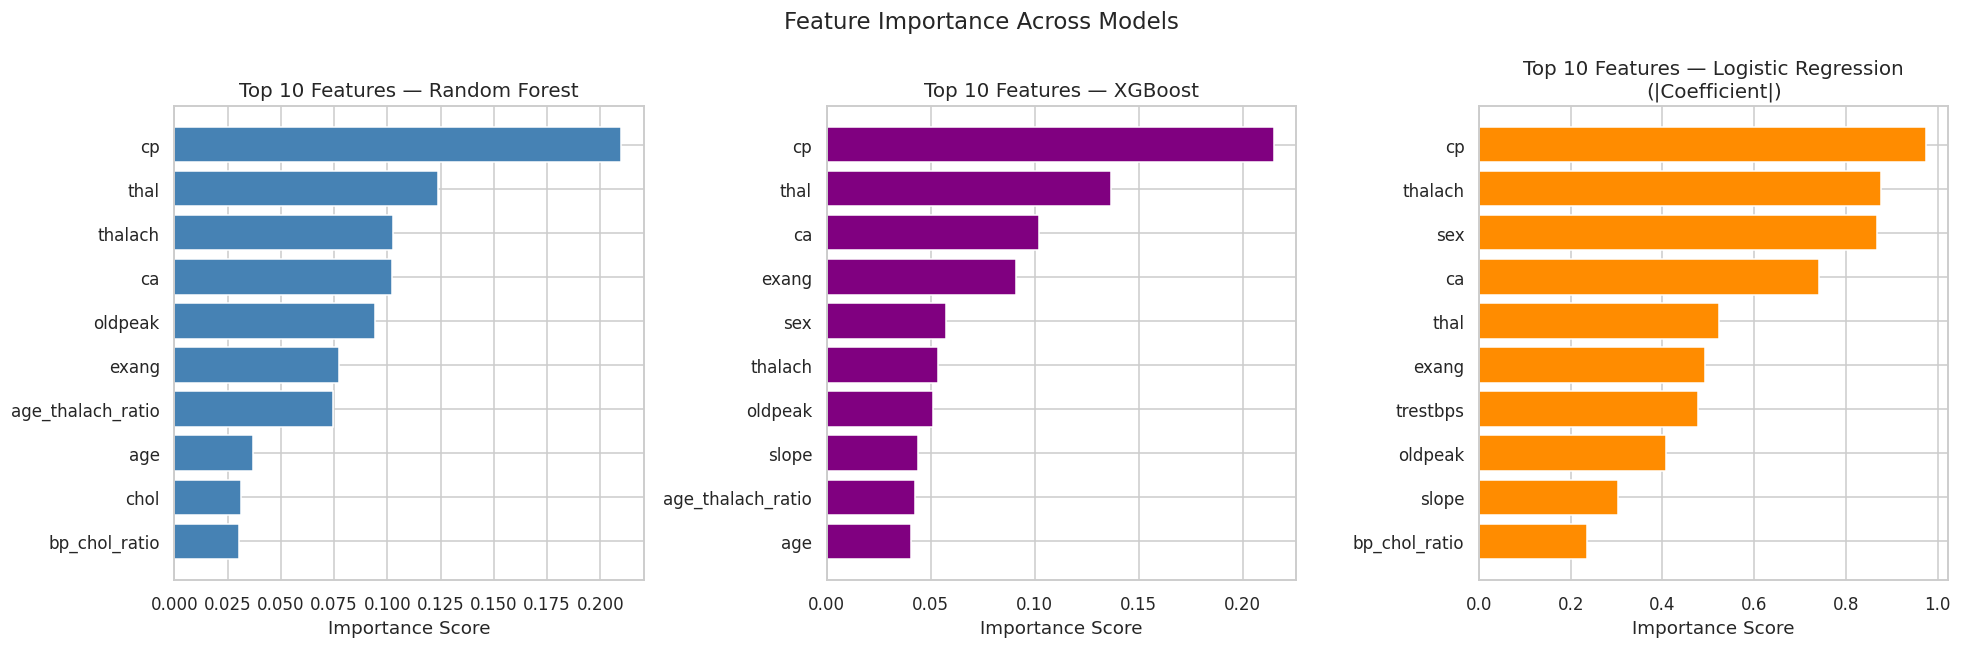


── Clinical Interpretation of Top Features ─────────────────
  cp          : Chest pain type — key symptom, asymptomatic = highest risk
  thalach     : Max heart rate — lower max HR associated with disease
  oldpeak     : ST depression — higher value = more ischemia
  ca          : Number of blocked vessels — directly indicates severity
  thal        : Thalassemia type — reversible defect = high risk
  age         : Older patients carry higher baseline risk
  exang       : Exercise-induced angina — chest pain during exertion


In [38]:
rf_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'RF_Importance': rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)

# XGBoost feature importance
xgb_imp = pd.DataFrame({
    'Feature'        : feature_names,
    'XGB_Importance' : xgb.feature_importances_
}).sort_values('XGB_Importance', ascending=False)

# Logistic Regression coefficients
lr_coef = pd.DataFrame({
    'Feature'    : feature_names,
    'LR_Coef'    : np.abs(lr.coef_[0])
}).sort_values('LR_Coef', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, df_imp, col, color, title in [
    (axes[0], rf_imp,  'RF_Importance',  'steelblue', 'Random Forest'),
    (axes[1], xgb_imp, 'XGB_Importance', 'purple',    'XGBoost'),
    (axes[2], lr_coef, 'LR_Coef',        'darkorange', 'Logistic Regression\n(|Coefficient|)')
]:
    top = df_imp.head(10)
    ax.barh(top['Feature'][::-1], top[col][::-1], color=color)
    ax.set_title(f'Top 10 Features — {title}')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Across Models', fontsize=15)
plt.tight_layout()
plt.show()

print("\n── Clinical Interpretation of Top Features ─────────────────")
clinical = {
    'cp'      : 'Chest pain type — key symptom, asymptomatic = highest risk',
    'thalach' : 'Max heart rate — lower max HR associated with disease',
    'oldpeak' : 'ST depression — higher value = more ischemia',
    'ca'      : 'Number of blocked vessels — directly indicates severity',
    'thal'    : 'Thalassemia type — reversible defect = high risk',
    'age'     : 'Older patients carry higher baseline risk',
    'exang'   : 'Exercise-induced angina — chest pain during exertion'
}
for feat, desc in clinical.items():
    print(f"  {feat:12s}: {desc}")

In [39]:
import joblib

joblib.dump(lr,           'lr_heart.pkl')
joblib.dump(svm,          'svm_heart.pkl')
joblib.dump(rf,           'rf_heart.pkl')
joblib.dump(xgb,          'xgb_heart.pkl')
joblib.dump(scaler,       'scaler_heart.pkl')
joblib.dump(feature_names,'features_heart.pkl')

print("✅ All models saved!")

✅ All models saved!
